In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
try:
    data = pd.read_csv("Movies.csv", encoding='utf-8')
except UnicodeDecodeError:
    try:
        data = pd.read_csv("Movies.csv", encoding='latin1')
    except UnicodeDecodeError:
        data = pd.read_csv("Movies.csv", encoding='iso-8859-1')

In [3]:
data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
...,...,...,...,...,...,...,...,...,...,...
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [5]:
data.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [6]:
data.shape

(15509, 10)

In [7]:
data.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [8]:
nulls = data[data.iloc[:, 1:9].isnull().all(axis=1)]
nulls

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1836,Bang Bang Reloaded,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1920,Battle of bittora,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2653,Campus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3403,Dancing Dad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3807,Dial 100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4271,Durga Rani Singh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8669,Main Hoon Kaun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9600,Mughal Road,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
data.dropna(subset=['Name', 'Year', 'Duration', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3'], inplace=True)
data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
...,...,...,...,...,...,...,...,...,...,...
15493,Zubaan,(2015),115 min,Drama,6.1,408,Mozez Singh,Vicky Kaushal,Sarah Jane Dias,Raaghavv Chanana
15494,Zubeidaa,(2001),153 min,"Biography, Drama, History",6.2,"1,496",Shyam Benegal,Karisma Kapoor,Rekha,Manoj Bajpayee
15503,Zulm Ki Zanjeer,(1989),125 min,"Action, Crime, Drama",5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani


In [10]:
for col in data.select_dtypes(include = "object"):
    print(f"Name of Column: {col}")
    print(data[col].unique())
    print('\n', '-'*60, '\n')

Name of Column: Name
['#Gadhvi (He thought he was Gandhi)' '#Yaaram' '...Aur Pyaar Ho Gaya' ...
 'Zulm Ki Zanjeer' 'Zulmi' 'Zulm-O-Sitam']

 ------------------------------------------------------------ 

Name of Column: Year
['(2019)' '(1997)' '(2005)' '(2012)' '(2014)' '(2004)' '(2016)' '(1991)'
 '(2018)' '(2010)' '(1958)' '(2021)' '(2017)' '(2009)' '(1993)' '(2002)'
 '(2008)' '(1994)' '(2007)' '(2003)' '(1998)' '(1979)' '(1974)' '(2015)'
 '(2006)' '(1981)' '(2020)' '(1985)' '(2013)' '(2011)' '(1988)' '(1987)'
 '(1999)' '(1973)' '(1968)' '(1982)' '(1977)' '(1950)' '(1969)' '(1948)'
 '(1990)' '(1989)' '(2001)' '(2000)' '(1953)' '(1978)' '(1963)' '(1992)'
 '(1976)' '(1984)' '(1986)' '(1966)' '(1975)' '(1980)' '(1967)' '(1970)'
 '(1952)' '(1972)' '(1971)' '(1964)' '(1954)' '(1962)' '(1957)' '(1965)'
 '(1996)' '(1995)' '(1956)' '(1955)' '(1936)' '(1983)' '(1951)' '(1961)'
 '(1959)' '(1949)' '(1960)' '(1946)' '(1940)' '(1945)' '(1938)' '(1941)'
 '(1942)' '(1935)' '(1937)' '(1934)' '(1947)'

In [11]:
data['Name'] = data['Name'].str.extract('([A-Za-z0-9\s\'\-]+)')
data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,Gadhvi,(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
...,...,...,...,...,...,...,...,...,...,...
15493,Zubaan,(2015),115 min,Drama,6.1,408,Mozez Singh,Vicky Kaushal,Sarah Jane Dias,Raaghavv Chanana
15494,Zubeidaa,(2001),153 min,"Biography, Drama, History",6.2,"1,496",Shyam Benegal,Karisma Kapoor,Rekha,Manoj Bajpayee
15503,Zulm Ki Zanjeer,(1989),125 min,"Action, Crime, Drama",5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani


In [12]:
data['Year'] = data['Year'].str.replace(r'[()]', '', regex=True).astype(int)
data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,Gadhvi,2019,109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,Yaaram,2019,110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,Aur Pyaar Ho Gaya,1997,147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,Yahaan,2005,142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,A Question Mark,2012,82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
...,...,...,...,...,...,...,...,...,...,...
15493,Zubaan,2015,115 min,Drama,6.1,408,Mozez Singh,Vicky Kaushal,Sarah Jane Dias,Raaghavv Chanana
15494,Zubeidaa,2001,153 min,"Biography, Drama, History",6.2,"1,496",Shyam Benegal,Karisma Kapoor,Rekha,Manoj Bajpayee
15503,Zulm Ki Zanjeer,1989,125 min,"Action, Crime, Drama",5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15505,Zulmi,1999,129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani


In [13]:
data['Duration'] = pd.to_numeric(data['Duration'].str.replace(r' min', '', regex=True), errors='coerce')
data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,Gadhvi,2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,Yaaram,2019,110,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,Aur Pyaar Ho Gaya,1997,147,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,Yahaan,2005,142,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,A Question Mark,2012,82,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
...,...,...,...,...,...,...,...,...,...,...
15493,Zubaan,2015,115,Drama,6.1,408,Mozez Singh,Vicky Kaushal,Sarah Jane Dias,Raaghavv Chanana
15494,Zubeidaa,2001,153,"Biography, Drama, History",6.2,"1,496",Shyam Benegal,Karisma Kapoor,Rekha,Manoj Bajpayee
15503,Zulm Ki Zanjeer,1989,125,"Action, Crime, Drama",5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15505,Zulmi,1999,129,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani


In [14]:
data['Genre'] = data['Genre'].str.split(', ')
data = data.explode('Genre')
data['Genre'].fillna(data['Genre'].mode()[0], inplace=True)
data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,Gadhvi,2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,Yaaram,2019,110,Comedy,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
3,Yaaram,2019,110,Romance,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,Aur Pyaar Ho Gaya,1997,147,Comedy,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
5,Aur Pyaar Ho Gaya,1997,147,Drama,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
...,...,...,...,...,...,...,...,...,...,...
15503,Zulm Ki Zanjeer,1989,125,Drama,5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15505,Zulmi,1999,129,Action,4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15505,Zulmi,1999,129,Drama,4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15508,Zulm-O-Sitam,1998,130,Action,6.2,20,K.C. Bokadia,Dharmendra,Jaya Prada,Arjun Sarja


In [15]:
data['Votes'] = pd.to_numeric(data['Votes'].str.replace(',', ''), errors='coerce')
data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,Gadhvi,2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,Yaaram,2019,110,Comedy,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
3,Yaaram,2019,110,Romance,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,Aur Pyaar Ho Gaya,1997,147,Comedy,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
5,Aur Pyaar Ho Gaya,1997,147,Drama,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
...,...,...,...,...,...,...,...,...,...,...
15503,Zulm Ki Zanjeer,1989,125,Drama,5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15505,Zulmi,1999,129,Action,4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15505,Zulmi,1999,129,Drama,4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15508,Zulm-O-Sitam,1998,130,Action,6.2,20,K.C. Bokadia,Dharmendra,Jaya Prada,Arjun Sarja


In [16]:
duplicate = data.groupby(['Name', 'Year']).filter(lambda x: len(x) > 1)
duplicate

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
3,Yaaram,2019,110,Comedy,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
3,Yaaram,2019,110,Romance,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,Aur Pyaar Ho Gaya,1997,147,Comedy,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
5,Aur Pyaar Ho Gaya,1997,147,Drama,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
5,Aur Pyaar Ho Gaya,1997,147,Musical,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
...,...,...,...,...,...,...,...,...,...,...
15503,Zulm Ki Zanjeer,1989,125,Drama,5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15505,Zulmi,1999,129,Action,4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15505,Zulmi,1999,129,Drama,4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15508,Zulm-O-Sitam,1998,130,Action,6.2,20,K.C. Bokadia,Dharmendra,Jaya Prada,Arjun Sarja


In [17]:
data = data.drop_duplicates(subset=['Name'], keep='first')
data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,Gadhvi,2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,Yaaram,2019,110,Comedy,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,Aur Pyaar Ho Gaya,1997,147,Comedy,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,Yahaan,2005,142,Drama,7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,A Question Mark,2012,82,Horror,5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
...,...,...,...,...,...,...,...,...,...,...
15493,Zubaan,2015,115,Drama,6.1,408,Mozez Singh,Vicky Kaushal,Sarah Jane Dias,Raaghavv Chanana
15494,Zubeidaa,2001,153,Biography,6.2,1496,Shyam Benegal,Karisma Kapoor,Rekha,Manoj Bajpayee
15503,Zulm Ki Zanjeer,1989,125,Action,5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15505,Zulmi,1999,129,Action,4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani


In [18]:
data.describe(include='O')

,Name,Genre,Director,Actor 1,Actor 2,Actor 3
count,5324,5324,5324,5324,5324,5324
unique,5324,20,2378,1911,2266,2486
top,Gadhvi,Drama,David Dhawan,Amitabh Bachchan,Rekha,Pran
freq,1,1755,36,94,47,53


In [19]:
max_votes_row = data[data['Votes'] == data['Votes'].max()]
max_votes_row

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
8219,Life of Pi,2012,127,Adventure,7.9,591417,Ang Lee,Suraj Sharma,Irrfan Khan,Adil Hussain


In [20]:
min_votes_row = data[data['Votes'] == data['Votes'].min()]
min_votes_row

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1116,Anmol Sitaare,1982,153,Drama,7.0,5,Geethapriya,Master Baboo,Rakesh Bedi,Ramesh Deo
1341,Atal Faisla,2018,127,Drama,8.8,5,Abdul Sattar,Sahil Akhtar,Himayat Ali,Aman Jain
1434,Awesome Mausam,2016,131,Romance,3.6,5,Yogesh Bharadwaj,Vaarssh Bhatnagar,Sunil Chaurasiyaa,Suhasini Mulay
1469,B for Bundelkhand,2017,117,Drama,8.8,5,Vishal Mourya,Bharat Chawla,Nemi Chandra Jha,Moumita Nandi
2118,Bhai-Bahen,1959,136,Drama,6.0,5,G.P. Sippy,Daisy Irani,Rajan Kapoor,Kathana
2843,Chandidas,1934,128,Drama,6.6,5,Nitin Bose,K.L. Saigal,Umasashi,Pahadi Sanyal
3061,Chipku,2016,135,Drama,6.8,5,Priyanka,Gouri Ash,Rakesh Bedi,Neha Pal Chowdhury
3361,Daku Kali Bhawani,2000,120,Action,3.8,5,S.R. Pratap,Dharmendra,Milind Gunaji,Mohan Joshi
4021,Do Ghadi Ki Mouj,1935,153,Drama,5.4,5,Homi Master,Ruby Mayer,Dinshaw Bilimoria,Jillo
4046,Do Nambar Ke Amir,1974,136,Crime,7.2,5,P.D. Shenoy,Asha Sachdev,Sajid Khan,A.K. Hangal


In [21]:
max_rating_row = data[data['Rating'] == data['Rating'].max()]
max_rating_row

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
8339,Love Qubool Hai,2020,94,Drama,10.0,5,Saif Ali Sayeed,Ahaan Jha,Mahesh Narayan,Rajasree Rajakumari


In [22]:
min_rating_row = data[data['Rating'] == data['Rating'].min()]
min_rating_row

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
12171,Sadak 2,2020,133,Action,1.1,67785,Mahesh Bhatt,Alia Bhatt,Priyanka Bose,Sanjay Dutt


C:\Users\DELL\AppData\Local\Temp\ipykernel_22568\3596243857.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Year_binned'] = pd.cut(data['Year'], bins=bins, right=False)


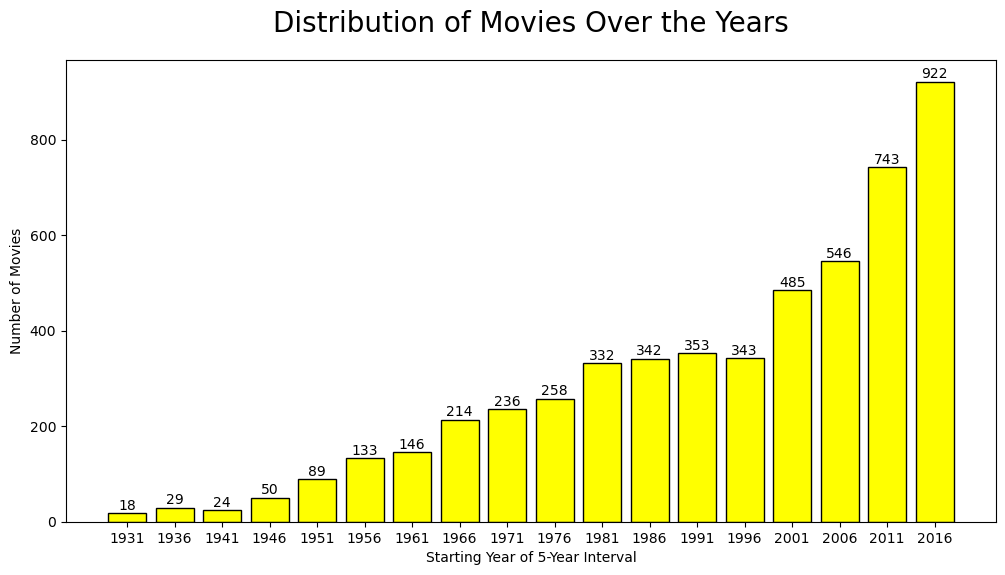

In [23]:
bins = range(int(data['Year'].min()), int(data['Year'].max()) + 5, 5)
data['Year_binned'] = pd.cut(data['Year'], bins=bins, right=False)
year_counts = data['Year_binned'].value_counts().sort_index()
bin_labels = [str(interval.left) for interval in year_counts.index]

plt.figure(figsize=(12, 6))
bars = plt.bar(bin_labels, year_counts.values, color='yellow', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1, int(yval), ha='center', va='bottom')

plt.title('Distribution of Movies Over the Years', pad=20, fontsize=20)
plt.xlabel('Starting Year of 5-Year Interval')
plt.ylabel('Number of Movies')
plt.gca().set_facecolor('white')
plt.grid(False)

plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_22568\2360534665.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["Rating"])


Text(0.5, 1.0, 'Distribution of movie ratings')

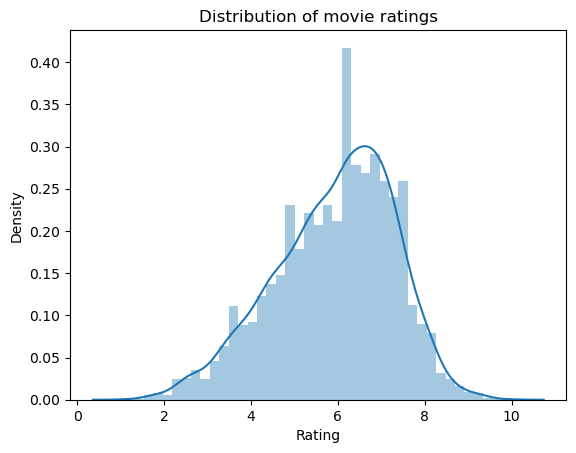

In [24]:
sns.distplot(data["Rating"])
plt.title("Distribution of movie ratings")

Text(0.5, 1.0, 'does duration affects the rating')

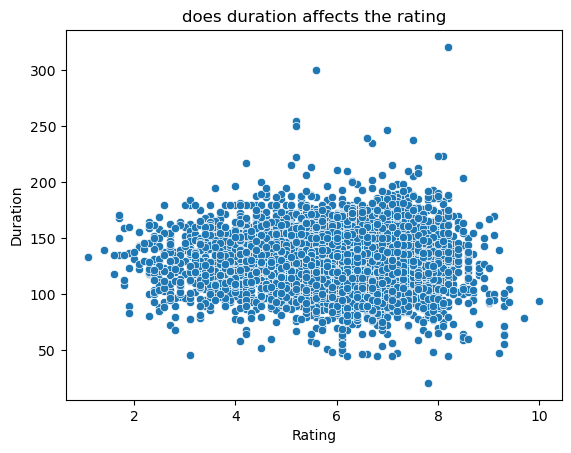

In [25]:
sns.scatterplot(y="Duration",x="Rating",data=data)
plt.title("does duration affects the rating")

Text(0.5, 1.0, 'Popular Actor ')

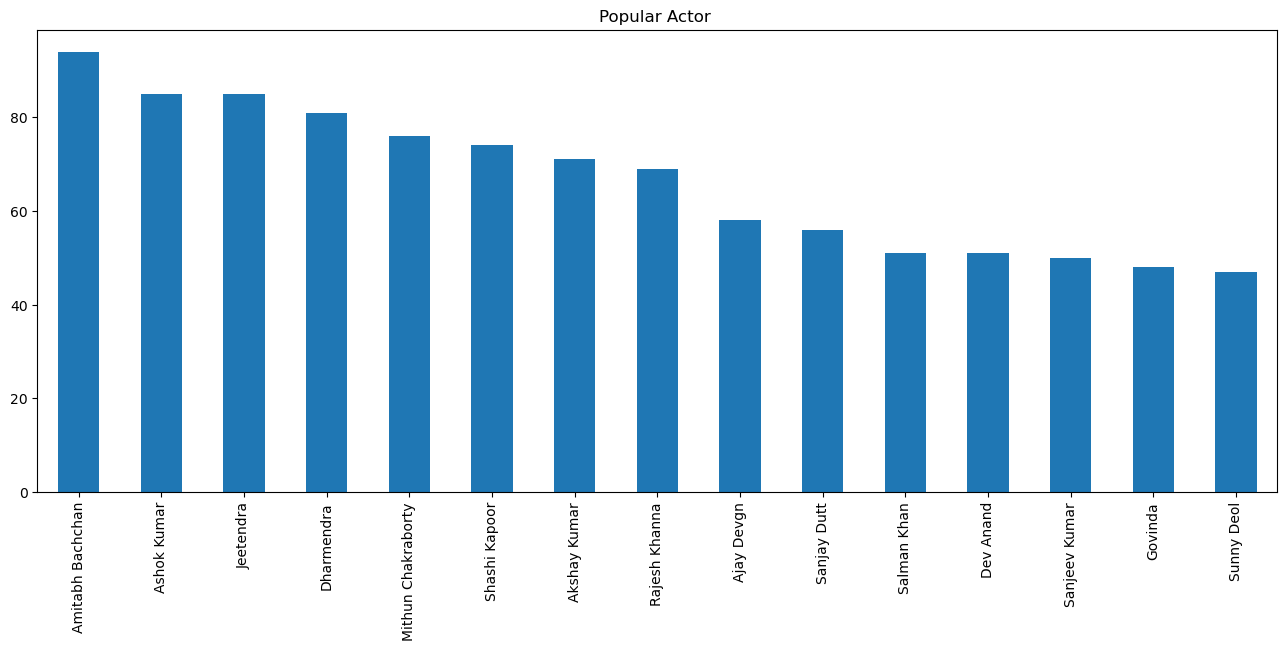

In [26]:
plt.figure(figsize=(16,6))
Ac=data["Actor 1"].value_counts(ascending=False)[:15].plot(kind="bar")
plt.xticks(rotation=90)
plt.title("Popular Actor ")

Text(0.5, 1.0, 'Popular Actor ')

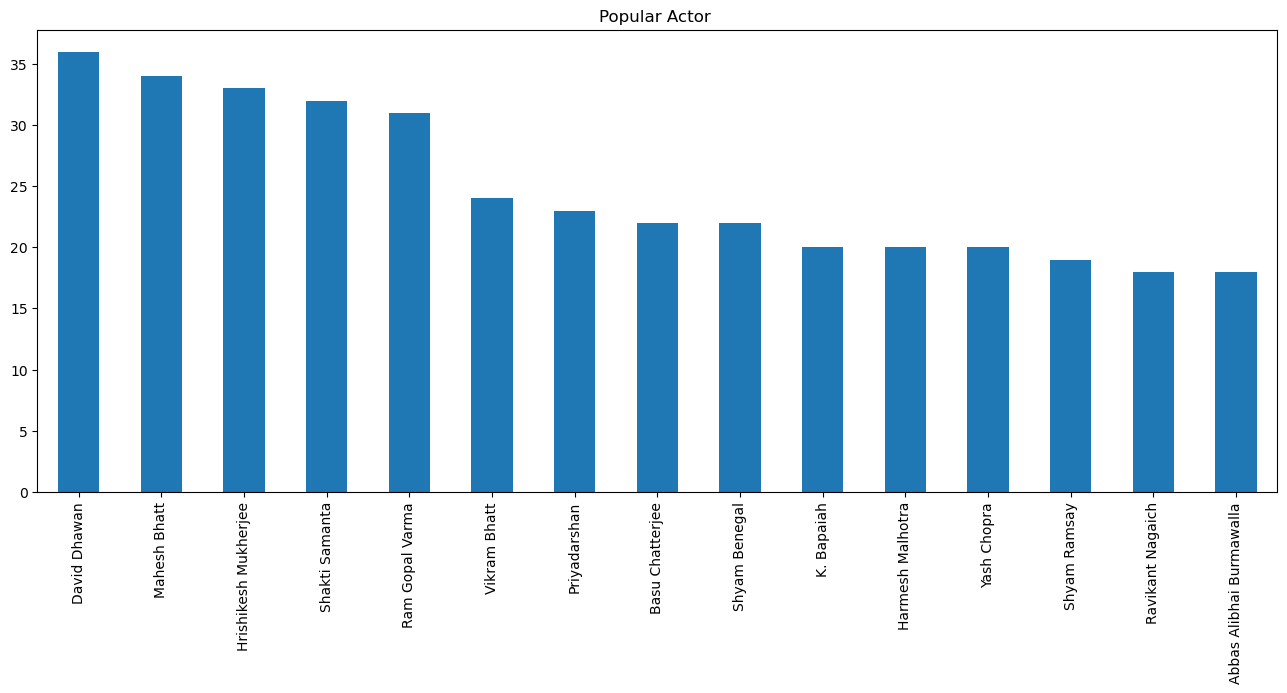

In [27]:
plt.figure(figsize=(16,6))
Ac=data["Director"].value_counts(ascending=False)[:15].plot(kind="bar")
plt.xticks(rotation=90)
plt.title("Popular Actor ")

In [28]:
top_10=data[["Year","Name","Genre","Duration"]].sort_values(by="Duration",ascending=False).head(10)
print("TOP_10 based on Duration")
top_10

TOP_10 based on Duration


,Year,Name,Genre,Duration
4902,2012,Gangs of Wasseypur,Action,321
1345,2007,Athidhi,Action,300
8251,2003,LOC,Drama,255
14854,2006,Vidhyaarthi,Action,250
6553,1965,Janwar,Musical,247
14809,1994,Veera,Comedy,240
14938,1998,Vivekananda,Biography,240
12365,1964,Sangam,Drama,238
13713,2003,Taj Mahal,Drama,235
8035,2001,Lagaan,Drama,224


In [29]:
top_10=data[["Year","Name","Genre","Rating"]].sort_values(by="Rating",ascending=False).head(10)
print("TOP_10 based on ratings")
top_10

TOP_10 based on ratings


,Year,Name,Genre,Rating
8339,2020,Love Qubool Hai,Drama,10.0
5410,2021,Half Songs,Music,9.7
5077,2019,Gho Gho Rani,History,9.4
14222,2020,The Reluctant Crime,Drama,9.4
6852,2021,June,Drama,9.4
5125,2019,God of gods,Documentary,9.3
1729,2021,Baikunth,Family,9.3
11843,2021,Refl3ct,Sci-Fi,9.3
1314,2018,Ashok Vatika,Drama,9.3
8344,2021,Love Sorries,Comedy,9.3


In [30]:
top_10=data[["Year","Name","Genre","Votes"]].sort_values(by="Votes",ascending=False).head(10)
print("TOP_10 based on votes")
top_10

TOP_10 based on votes


,Year,Name,Genre,Votes
8219,2012,Life of Pi,Adventure,591417
75,2009,3 Idiots,Comedy,357889
8233,2016,Lion,Biography,220526
4848,1982,Gandhi,Biography,220118
14038,2007,The Darjeeling Limited,Adventure,185127
8228,2007,Like Stars on Earth,Drama,175810
10882,2014,PK,Comedy,168150
3410,2016,Dangal,Action,165074
11463,2021,Radhe,Action,162455
3829,2020,Dil Bechara,Comedy,117377


In [31]:
data['Genre encoded'] = round(data.groupby('Genre')['Rating'].transform('mean'),1)
data['Director encoded'] = round(data.groupby('Director')['Rating'].transform('mean'),1)
data['Actor 1 encoded'] = round(data.groupby('Actor 1')['Rating'].transform('mean'),1)
data['Actor 2 encoded'] = round(data.groupby('Actor 2')['Rating'].transform('mean'),1)
data['Actor 3 encoded'] = round(data.groupby('Actor 3')['Rating'].transform('mean'),1)

data.drop(columns=['Genre','Director','Actor 1','Actor 2','Actor 3'],inplace=True)
data['Rating'] = round(data['Rating'],1)

C:\Users\DELL\AppData\Local\Temp\ipykernel_22568\4271116222.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Genre encoded'] = round(data.groupby('Genre')['Rating'].transform('mean'),1)
C:\Users\DELL\AppData\Local\Temp\ipykernel_22568\4271116222.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Director encoded'] = round(data.groupby('Director')['Rating'].transform('mean'),1)
C:\Users\DELL\AppData\Local\Temp\ipykernel_22568\4271116222.py:3: SettingWithCopyWarning: 
A value is trying to be s

In [32]:
data

,Name,Year,Duration,Rating,Votes,Year_binned,Genre encoded,Director encoded,Actor 1 encoded,Actor 2 encoded,Actor 3 encoded
1,Gadhvi,2019,109,7.0,8,"[2016, 2021)",6.3,7.0,6.8,7.0,7.0
3,Yaaram,2019,110,4.4,35,"[2016, 2021)",5.8,4.4,5.4,4.4,4.4
5,Aur Pyaar Ho Gaya,1997,147,4.7,827,"[1996, 2001)",5.8,5.2,4.9,5.8,5.9
6,Yahaan,2005,142,7.4,1086,"[2001, 2006)",6.3,7.4,5.4,6.9,6.7
8,A Question Mark,2012,82,5.6,326,"[2011, 2016)",4.7,5.6,5.6,5.9,5.6
...,...,...,...,...,...,...,...,...,...,...,...
15493,Zubaan,2015,115,6.1,408,"[2011, 2016)",6.3,6.1,7.2,6.1,5.8
15494,Zubeidaa,2001,153,6.2,1496,"[2001, 2006)",6.7,7.2,4.2,5.8,6.0
15503,Zulm Ki Zanjeer,1989,125,5.8,44,"[1986, 1991)",5.5,6.3,6.3,5.8,6.0
15505,Zulmi,1999,129,4.5,655,"[1996, 2001)",5.5,5.2,5.5,4.8,5.7


C:\Users\DELL\AppData\Local\Temp\ipykernel_22568\2578434383.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(data.corr(),annot=True)


<Axes: >

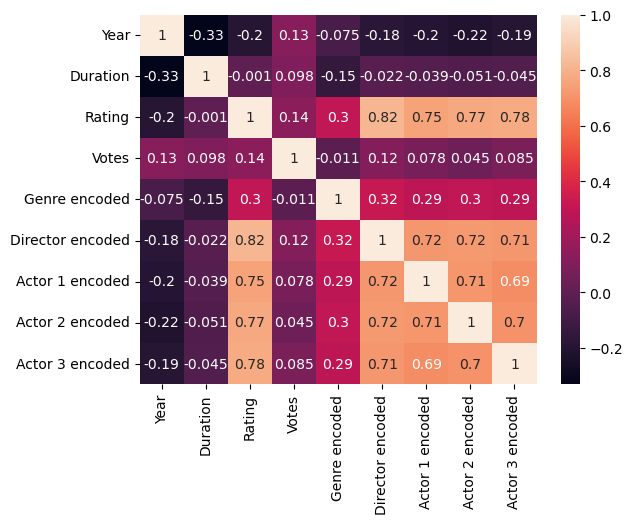

In [33]:
sns.heatmap(data.corr(),annot=True)

In [34]:
missing_values = data.isna().sum()
missing_values

Name                 0
Year                 0
Duration             0
Rating               0
Votes                0
Year_binned         61
Genre encoded        0
Director encoded     0
Actor 1 encoded      0
Actor 2 encoded      0
Actor 3 encoded      0
dtype: int64

In [35]:
df = data.dropna()
df

,Name,Year,Duration,Rating,Votes,Year_binned,Genre encoded,Director encoded,Actor 1 encoded,Actor 2 encoded,Actor 3 encoded
1,Gadhvi,2019,109,7.0,8,"[2016, 2021)",6.3,7.0,6.8,7.0,7.0
3,Yaaram,2019,110,4.4,35,"[2016, 2021)",5.8,4.4,5.4,4.4,4.4
5,Aur Pyaar Ho Gaya,1997,147,4.7,827,"[1996, 2001)",5.8,5.2,4.9,5.8,5.9
6,Yahaan,2005,142,7.4,1086,"[2001, 2006)",6.3,7.4,5.4,6.9,6.7
8,A Question Mark,2012,82,5.6,326,"[2011, 2016)",4.7,5.6,5.6,5.9,5.6
...,...,...,...,...,...,...,...,...,...,...,...
15493,Zubaan,2015,115,6.1,408,"[2011, 2016)",6.3,6.1,7.2,6.1,5.8
15494,Zubeidaa,2001,153,6.2,1496,"[2001, 2006)",6.7,7.2,4.2,5.8,6.0
15503,Zulm Ki Zanjeer,1989,125,5.8,44,"[1986, 1991)",5.5,6.3,6.3,5.8,6.0
15505,Zulmi,1999,129,4.5,655,"[1996, 2001)",5.5,5.2,5.5,4.8,5.7


In [36]:
df.isna().sum()

Name                0
Year                0
Duration            0
Rating              0
Votes               0
Year_binned         0
Genre encoded       0
Director encoded    0
Actor 1 encoded     0
Actor 2 encoded     0
Actor 3 encoded     0
dtype: int64

In [37]:
X = df[['Year','Genre encoded', 'Votes','Actor 1 encoded','Actor 2 encoded','Actor 3 encoded','Director encoded']]
y = df['Rating']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3684, 7)
(3684,)
(1579, 7)
(1579,)


In [39]:
model_rf=RandomForestRegressor()
model_rf.fit(X_train,y_train)
y_pred_rf=model_rf.predict(X_test)
mse_rf = mean_squared_error(y_test,y_pred_rf)
r2_rf = r2_score(y_test,y_pred_rf)
print("RANDOM FOREST")
print('Mean Squared Error:',mse_rf.round(2))
print('R2_Score:',r2_rf.round(2))

RANDOM FOREST
Mean Squared Error: 0.33
R2_Score: 0.81


In [40]:
model_svr=SVR(kernel='rbf')
model_svr.fit(X_train,y_train)
y_pred_svr=model_svr.predict(X_test)
mse_svr = mean_squared_error(y_test,y_pred_svr)
r2_svr = r2_score(y_test,y_pred_svr)
print("SVR")
print('Mean Squared Error:',mse_svr.round(2))
print('R2_Score:',r2_svr.round(2))

SVR
Mean Squared Error: 1.76
R2_Score: 0.01


In [41]:
model_lr=LinearRegression()
model_lr.fit(X_train,y_train)
y_pred_lr=model_lr.predict(X_test)
mse_lr = mean_squared_error(y_test,y_pred_lr)
r2_lr = r2_score(y_test,y_pred_lr)
print("LINEAR REGRESSION")
print('Mean Squared Error:',mse_lr.round(2))
print('R2_Score:',r2_lr.round(2))

LINEAR REGRESSION
Mean Squared Error: 0.4
R2_Score: 0.78


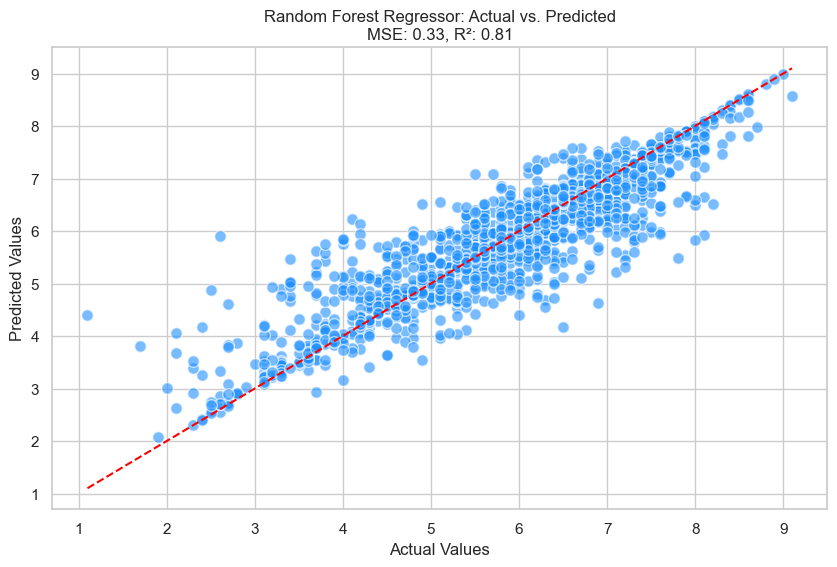

In [42]:
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

plt.scatter(y_test, y_pred_rf, color='dodgerblue', alpha=0.6, edgecolors='w', s=70)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color='red')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest Regressor: Actual vs. Predicted\nMSE: {:.2f}, R²: {:.2f}'.format(mse_rf, r2_rf))

plt.grid(True)
plt.show()

In [43]:
X.head()

,Year,Genre encoded,Votes,Actor 1 encoded,Actor 2 encoded,Actor 3 encoded,Director encoded
1,2019,6.3,8,6.8,7.0,7.0,7.0
3,2019,5.8,35,5.4,4.4,4.4,4.4
5,1997,5.8,827,4.9,5.8,5.9,5.2
6,2005,6.3,1086,5.4,6.9,6.7,7.4
8,2012,4.7,326,5.6,5.9,5.6,5.6


In [44]:
y.head()

1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64

In [45]:
data = {
    'Year': [2019],
    'Genre encoded': [5.8],
    'Votes': [827],
    'Actor 1 encoded': [4.9],
    'Actor 2 encoded': [5.8],
    'Actor 3 encoded': [5.9],
    'Director encoded': [5.2]
}
new_input_df = pd.DataFrame(data)
predicted_rating_rf = model_rf.predict(new_input_df)
print("Predicted Rating:", predicted_rating_rf[0])

Predicted Rating: 4.738999999999999
